## Hierarchical Clustering (Agglomerative)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Load the Iris dataset

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

# convert to a dataframe with column names
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Scale the features

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)  # mean 0, std 1
X[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

### Reduce to 2 features using PCA

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

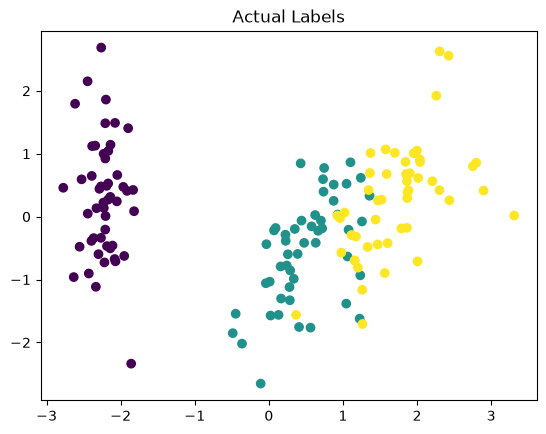

In [5]:
# actual flower types (just to compare later)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris.target)
plt.title("Actual Labels")
plt.show()

### Dendrogram

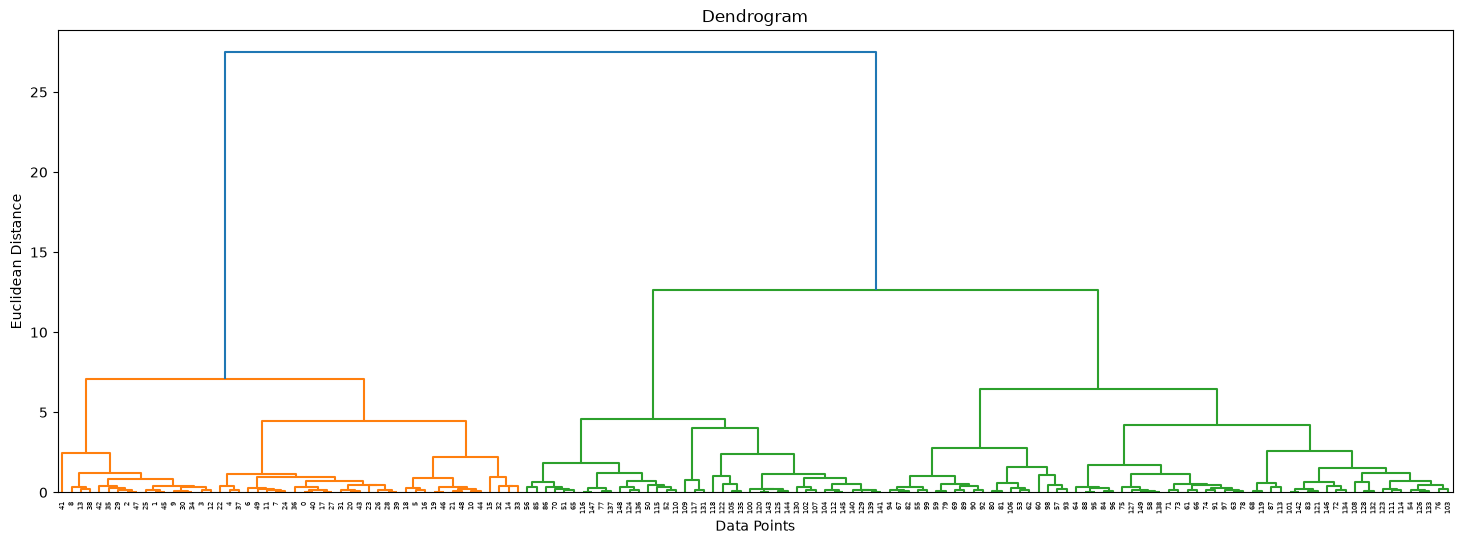

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(18, 6))
dendrogram(linkage(X_pca, method="ward"))  # ward = merge clusters with least variance
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

### Agglomerative Clustering

In [7]:
from sklearn.cluster import AgglomerativeClustering

# pick number of clusters from the dendrogram
model = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels = model.fit_predict(X_pca)
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

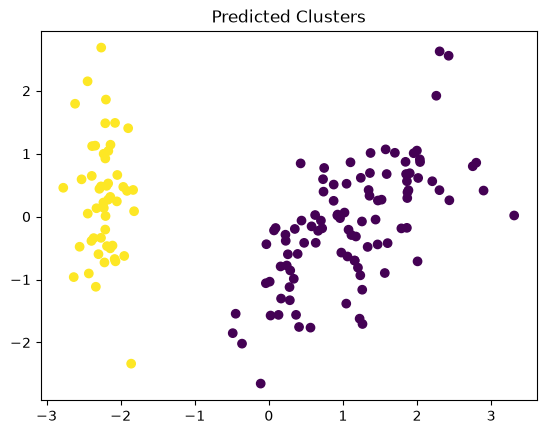

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("Predicted Clusters")
plt.show()

### Silhouette Score (find best number of clusters)

In [9]:
from sklearn.metrics import silhouette_score

scores = []

# silhouette needs at least 2 clusters
for k in range(2, 11):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

scores

[0.614520203623045,
 0.511059598876619,
 0.4487350420958891,
 0.4041689631006267,
 0.36721128895830735,
 0.3706820678912666,
 0.3930552606912111,
 0.4183694466469872,
 0.405420562888949]

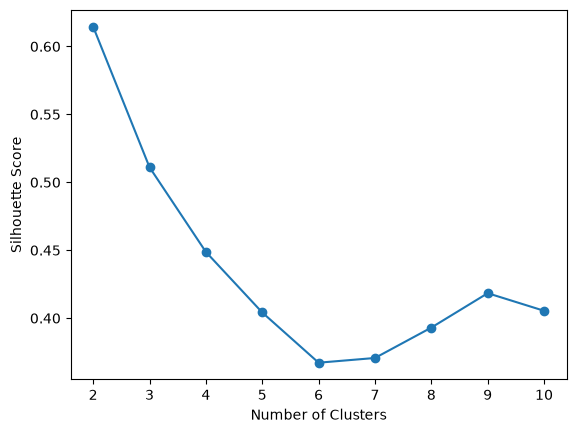

In [10]:
# higher score = better clusters
plt.plot(range(2, 11), scores, marker="o")
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()